In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from tqdm import tqdm

# Fonctions

In [106]:
def initialisation(input_dim, n1, n2, output_dim):

    W1 = np.random.randn(n1, input_dim)
    b1 = np.zeros((n1, 1))
    W2 = np.random.randn(n2, n1)
    b2 = np.zeros((n2, 1))
    W3 = np.random.randn(output_dim, n2)
    
    b3 = np.zeros((output_dim, 1))

    parametres = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2,
        'W3': W3,
        'b3': b3
    }

    return parametres

In [ ]:
def sigmoid(Z):
    # éviter overflow : np.clip limite les valeurs trop grandes/petites
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

In [108]:
def forward_propagation(X, parametres):

    W1 = parametres['W1']
    b1 = parametres['b1']
    W2 = parametres['W2']
    b2 = parametres['b2']
    W3 = parametres['W3']
    b3 = parametres['b3']

   
    Z1 = W1.dot(X) + b1
    A1 = sigmoid(Z1)
    
  

    Z2 = W2.dot(A1) + b2
    A2 = sigmoid(Z2)

   
    Z3 = W3.dot(A2) + b3
    A3 = np.copy(Z3) #pas d'activation sur la dernière couche pour une régression
   



    activations = {
        'A1': A1,
        'A2': A2,
        'A3': A3 
    }

    return activations

In [ ]:
def back_propagation(X, y, parametres, activations):

    A1 = activations['A1']
    A2 = activations['A2']
    A3 = activations['A3']
    W2 = parametres['W2']
    W3 = parametres['W3']


    m = y.shape[1]


    dZ3 =(2 / m) * (A3 - y)
    dW3 = dZ3.dot(A2.T)
    db3 = np.sum(dZ3, axis=1, keepdims = True)/m
    
    dZ2 = np.dot(W3.T, dZ3) * A2 * (1 - A2)
    dW2 = dZ2.dot(A1.T)
    db2 = np.sum(dZ2, axis=1, keepdims = True)/m

    dZ1 = np.dot(W2.T, dZ2) * A1 * (1 - A1)
    dW1 = dZ1.dot(X.T)
    db1 = np.sum(dZ1, axis=1, keepdims = True)/m

    gradients = {
        'dW1' : dW1,
        'db1' : db1,
        'dW2' : dW2,
        'db2' : db2,
        'dW3' : dW3,
        'db3' : db3
    }
    
    return gradients

In [110]:
def update(gradients, parametres, learning_rate):

    W1 = parametres['W1']
    b1 = parametres['b1']
    W2 = parametres['W2']
    b2 = parametres['b2']
    W3 = parametres['W3']
    b3 = parametres['b3']

    dW1 = gradients['dW1']
    db1 = gradients['db1']
    dW2 = gradients['dW2']
    db2 = gradients['db2']
    dW3 = gradients['dW3']
    db3 = gradients['db3']


    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2
    W3 = W3 - learning_rate * dW3
    b3 = b3 - learning_rate * db3


    parametres = {
        'W1': W1,
        'b1': b1,
        'W2': W2,
        'b2': b2,
        'W3': W3,
        'b3': b3
    }

    return parametres

In [111]:
def predict(X, parametres):
  activations = forward_propagation(X, parametres)
  A3 = activations['A3']
  return A3

In [ ]:
def neural_network(X, y, input_dim=3, output_dim=4, hidden_layers=[128,128], learning_rate = 0.0001, n_iter = 200):

    # initialisation parametres
    n1 = hidden_layers[0]
    n2 = hidden_layers[1]
    np.random.seed(0)
    parametres = initialisation(input_dim, n1, n2, output_dim)

    train_loss = []
    train_acc = []
    history = []

    # gradient descent
    for i in tqdm(range(n_iter)):
        activations = forward_propagation(X, parametres)
        A3 = activations['A3']

        # Plot courbe d'apprentissage
        #print(f'y.flatten() : {y.flatten().shape}, A3.flatten() : {A3.flatten().shape}')
        train_loss.append(mean_squared_error(y.flatten(), A3.flatten()))

        
        y_pred = predict(X, parametres)
        train_acc.append(r2_score(y.flatten(), y_pred.flatten()))
        
        history.append([parametres.copy(), train_loss, train_acc, i])

        # mise a jour
        gradients = back_propagation(X, y, parametres, activations)
        parametres = update(gradients, parametres, learning_rate)

        if i%1000 ==0 :
            print(f'training step : {i}, train loss : {train_loss[-1]}, train R2 score : {train_acc[-1]} ')


    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_loss, label='train loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(train_acc, label='train R2 score')
    plt.legend()
    plt.show()
    

    return parametres

# Dataset

In [113]:
from sklearn.neural_network import MLPRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import ast
import re

In [114]:
#Creation du dataset

df_data_raw= pd.read_csv("C:/Users/roccy/Downloads/blueleg_beam_sphere.csv", delimiter=';', skiprows=8)
# Shuffle the dataframe
df_shuffled = df_data_raw.sample(frac=1.0, random_state=42) # Added random_state for reproducibilit
# Split the dataframe into training and test sets
train_size = 0.8
df_data_training, df_data_test = train_test_split(df_shuffled, train_size=train_size, random_state=42) # Added random_state for reproducibilit
# Function to clean and evaluate the string representation of lists
def clean_and_eval_list_string(list_string):
    # Add commas between numbers in the string
    cleaned_string = re.sub(r'(?<=\d)\s+(?=[-\d])', ',', list_string)
    return ast.literal_eval(cleaned_string)
# Separate features (X) and target (y) for both training and test sets
X_train = np.array([clean_and_eval_list_string(pos) for pos in df_data_training['Effector position'].tolist()])
y_train = np.array([clean_and_eval_list_string(angle) for angle in df_data_training['Motor angle'].tolist()])
X_test = np.array([clean_and_eval_list_string(pos) for pos in df_data_test['Effector position'].tolist()])
y_test = np.array([clean_and_eval_list_string(angle) for angle in df_data_test['Motor angle'].tolist()])

In [115]:
X,y=X_train.T, y_train.T


  0%|          | 7/50000 [00:00<13:03, 63.78it/s]

training step : 0, train loss : 167.59762487561616, train R2 score : -364.058461140479 


  2%|▏         | 1004/50000 [00:24<45:58, 17.76it/s]

training step : 1000, train loss : 0.47794424411501546, train R2 score : -0.04105049458228782 


  4%|▍         | 2003/50000 [01:22<51:31, 15.53it/s]  

...

 96%|█████████▌| 48002/50000 [1:44:35<04:37,  7.20it/s]

training step : 48000, train loss : 0.1751394227026995, train R2 score : 0.6185141156724028 


 98%|█████████▊| 49002/50000 [1:47:18<02:53,  5.76it/s]

training step : 49000, train loss : 0.1748673960960519, train R2 score : 0.6191066396684065 


100%|██████████| 50000/50000 [1:53:14<00:00,  7.36it/s]


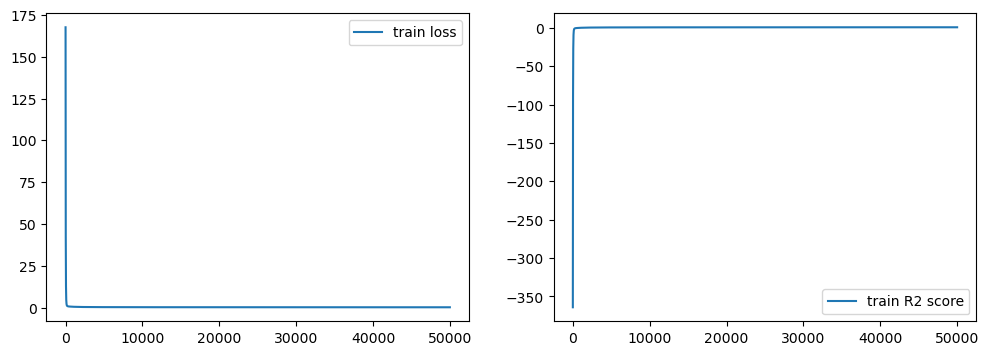

({'W1': array([[ 1.70896908,  0.64664895,  0.94319973],
         [ 2.2408932 ,  1.86755799, -0.97727788],
         [ 0.96204003, -0.11420442, -0.04169179],
         [ 0.39545981, -0.40643736,  1.40230471],
         [ 0.7370143 , -0.29502147,  0.40506163],
         [ 0.33367433,  1.49407907, -0.20515826],
         [ 0.31306989, -0.85435101, -2.55291047],
         [ 0.6536186 ,  0.8644362 , -0.74216502],
         [ 2.26975462, -1.45436567,  0.04575852],
         [-0.18718385,  1.53277921,  1.46935877],
         [ 0.15494802,  0.3781577 , -0.88778708],
         [-1.91301266, -0.62059278,  0.1521258 ],
         [ 1.23029068,  1.20237985, -0.38732682],
         [-0.30230275, -1.04855297, -1.42001794],
         [-1.70627019,  1.9507754 , -0.50965218],
         [-0.4380743 , -1.25279536,  0.77749036],
         [-1.53116637, -0.48222997, -0.9180408 ],
         [ 0.38690234, -0.51080627, -1.18063187],
         [-0.02818223,  0.42833187,  0.06651722],
         [ 0.3024719 , -0.63432209, -0.36274

In [122]:
neural_network(X, y,n_iter = 50000)